# Lunar Subsurface Ice Quantification from Chandrayaan-2 DFSAR  (v3)

### From detection to quantification: ice concentration and volume with uncertainty

**Objective.** Move beyond "is there ice?" to "how much ice, at what
concentration, with what uncertainty?" over a named permanently-shadowed cold
trap (Haworth crater), using L-band compact-polarimetry.

**Why this framing.** Binary ice segmentation on synthetic data saturates
trivially and is not a credible metric. Estimating the continuous ice volume
fraction is a genuinely hard inverse problem (speckle-limited), so it produces an
honest accuracy (R^2, RMSE) and, more importantly, a physically meaningful
product: ice concentration and total volume.

**Method.**
1. Physics-based synthetic generator: a continuous ice-fraction field drives the
   observed CPR/DOP through a monotonic relation plus multilook speckle.
2. A physics-informed U-Net regresses the ice fraction from CPR/DOP.
3. Dielectric inversion: Carrier (1991) regolith density + Looyenga-Landau-Lifshitz
   three-phase mixing relate fraction and effective permittivity.
4. Monte-Carlo propagation yields total ice volume with a 95% confidence interval.
5. The trained model is applied to the real Haworth DFSAR strip and geocoded.

**Polarimetry.** S0 = <|E_LH|^2+|E_LV|^2>, S3 = -2 Im<E_LH E_LV*>,
mu (CPR) = (S0 - S3)/(S0 + S3), m (DOP) = sqrt(S1^2+S2^2+S3^2)/S0.


## 1. Setup

In [ ]:
import os, sys, glob, json, time
import numpy as np
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.synth import SceneConfig, make_regression_dataset
from src.polarimetry import (ice_threshold_mask, physics_gate, stokes_from_compact, mchi_decomposition)
from src.train import (ChannelNormalizer, TrainConfig, train_regressor, predict,
                       regression_metrics)
from src.dataio import (dfsar_compact_features, predict_scene, find_compact_slc_in_zip,
                        read_complex_band)
from src import dielectric as di
from src import evaluation as ev
from src import geocode as gc
import rasterio
from rasterio.windows import Window

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| device:", DEVICE)
os.makedirs("models", exist_ok=True)
os.makedirs("outputs/figures_v3", exist_ok=True)
FIG = "outputs/figures_v3"


## 2. Configuration

In [ ]:
scene = SceneConfig(height=128, width=128, looks=6, ice_fraction=0.15,
                    rough_fraction=0.20, blob_scale=5.0, difficulty=0.5)

N_TRAIN, N_VAL, N_TEST = 3000, 500, 500
tcfg = TrainConfig(epochs=200, batch_size=24, lr=1e-3, base_width=32, depth=4,
                   dropout=0.10, patience=30, weight_decay=1e-4, device=DEVICE)

# Real-scene parameters
SENSING_DEPTH_M = 2.0          # L-band penetration in dry regolith
HAWORTH = dict(lat=(-87.8, -87.0), lon=(-6.0, -2.0))
print("regression target = ice volume fraction | scenes:", N_TRAIN, N_VAL, N_TEST)


## 3. Synthetic dataset (continuous ice fraction)

In [ ]:
t0 = time.time()
Xtr, Ytr = make_regression_dataset(N_TRAIN, scene, seed=1)
Xva, Yva = make_regression_dataset(N_VAL,   scene, seed=2)
Xte, Yte = make_regression_dataset(N_TEST,  scene, seed=3)
print("generated %d scenes in %.1fs" % (N_TRAIN+N_VAL+N_TEST, time.time()-t0))
print("ice fraction: mean %.3f | max %.3f | ice-bearing pixels %.1f%%"
      % (Ytr.mean(), Ytr.max(), 100*np.mean(Ytr > 0.05)))


### Example scene and the physical CPR/DOP relation

In [ ]:
sc, fr = Xtr[0], Ytr[0]
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
im0 = ax[0].imshow(sc[0], cmap="magma", vmin=0, vmax=2); ax[0].set_title("CPR (observed)"); ax[0].axis("off"); plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(sc[1], cmap="viridis", vmin=0, vmax=1); ax[1].set_title("DOP (observed)"); ax[1].axis("off"); plt.colorbar(im1, ax=ax[1], fraction=0.046)
im2 = ax[2].imshow(fr, cmap="cividis", vmin=0, vmax=0.4); ax[2].set_title("ice fraction (target)"); ax[2].axis("off"); plt.colorbar(im2, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.savefig(FIG+"/example_scene.png", dpi=150, bbox_inches="tight"); plt.show()


### Class separability in CPR-DOP feature space
Ice-bearing pixels (fraction >= 0.05) occupy the high-CPR, low-DOP corner; the
dashed lines mark the deterministic thresholds (CPR>1, DOP<0.13). Speckle blurs
the boundary, which motivates a spatial-context model rather than a hard rule.

In [ ]:
cpr = Xtr[:, 0].ravel(); dop = Xtr[:, 1].ravel(); yf = (Ytr.ravel() >= 0.05)
idx = np.random.default_rng(0).choice(len(cpr), size=min(20000, len(cpr)), replace=False)
plt.figure(figsize=(6, 5))
plt.scatter(cpr[idx][~yf[idx]], dop[idx][~yf[idx]], s=3, alpha=0.2, label="non-ice")
plt.scatter(cpr[idx][ yf[idx]], dop[idx][ yf[idx]], s=3, alpha=0.3, label="ice")
plt.axvline(1.0, ls="--", c="k"); plt.axhline(0.13, ls="--", c="k")
plt.xlim(0, 3); plt.ylim(0, 1)
plt.xlabel("CPR"); plt.ylabel("DOP"); plt.title("CPR-DOP feature space (training data)")
plt.legend(); plt.tight_layout(); plt.savefig(FIG+"/class_separability.png", dpi=150, bbox_inches="tight"); plt.show()


### Calibration check: synthetic vs real DFSAR CPR/DOP
The synthetic generator is only credible if its CPR/DOP statistics resemble real
data. The training distribution is overlaid on a real Haworth DFSAR window.

In [ ]:
_zips = sorted(glob.glob("data/raw/dfsar/*.zip"))
_ref_zip = next((z for z in _zips if "20251026t125618324" in z), _zips[0]) if _zips else None
if _ref_zip is not None:
    _ref = dfsar_compact_features(_ref_zip, az_start=150000, az_len=12000, looks=9)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(Xtr[:, 0].ravel(), bins=120, range=(0, 3), density=True, alpha=0.6, label="synthetic")
    ax[0].hist(_ref["cpr"].ravel(), bins=120, range=(0, 3), density=True, alpha=0.6, label="real DFSAR")
    ax[0].axvline(1.0, ls="--", c="k"); ax[0].set_xlabel("CPR"); ax[0].set_title("CPR distribution"); ax[0].legend()
    ax[1].hist(Xtr[:, 1].ravel(), bins=120, range=(0, 1), density=True, alpha=0.6, label="synthetic")
    ax[1].hist(_ref["dop"].ravel(), bins=120, range=(0, 1), density=True, alpha=0.6, label="real DFSAR")
    ax[1].axvline(0.13, ls="--", c="k"); ax[1].set_xlabel("DOP"); ax[1].set_title("DOP distribution"); ax[1].legend()
    plt.tight_layout(); plt.savefig(FIG+"/calibration_check.png", dpi=150, bbox_inches="tight"); plt.show()
    print("real reference window: %s" % os.path.basename(_ref_zip))
else:
    print("no DFSAR products found; skipping calibration check")


### Dielectric forward/inverse consistency
The Looyenga-Landau-Lifshitz model relates ice fraction and effective
permittivity given the Carrier depth-averaged grain fraction. The round-trip is
exact, which underpins the volume inversion.

In [ ]:
fg = di.depth_averaged_grain_fraction(SENSING_DEPTH_M)
fr_axis = np.linspace(0, 0.4, 50)
eps = di.looyenga_forward(fr_axis, fg)
inv = di.looyenga_invert_ice(eps, fg)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(fr_axis, eps); ax[0].set_xlabel("ice fraction"); ax[0].set_ylabel("eff. permittivity")
ax[0].set_title("Looyenga forward (grain frac %.2f)" % fg); ax[0].grid(alpha=0.3)
ax[1].plot(fr_axis, inv, label="recovered"); ax[1].plot(fr_axis, fr_axis, "k--", alpha=0.5, label="ideal")
ax[1].set_xlabel("true ice fraction"); ax[1].set_ylabel("inverted"); ax[1].set_title("inverse round-trip"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG+"/dielectric_consistency.png", dpi=150, bbox_inches="tight"); plt.show()


## 4. Normalization

In [ ]:
norm = ChannelNormalizer(log_channels=(0,)).fit(Xtr)
Xtr_n, Xva_n, Xte_n = norm.transform(Xtr), norm.transform(Xva), norm.transform(Xte)
print("normalizer fit on training data only (no leakage).")


## 5. Train the ice-fraction regressor

In [9]:
model, history, best_rmse = train_regressor(Xtr_n, Ytr, Xva_n, Yva, tcfg, verbose=True)
print("\nbest validation RMSE = %.4f" % best_rmse)


epoch  28/200 | loss 0.00012 | val RMSE 0.0077 | R2 0.947 | det IoU 0.830
epoch  29/200 | loss 0.00012 | val RMSE 0.0081 | R2 0.942 | det IoU 0.823
epoch  30/200 | loss 0.00012 | val RMSE 0.0081 | R2 0.942 | det IoU 0.825
epoch  31/200 | loss 0.00011 | val RMSE 0.0086 | R2 0.934 | det IoU 0.799
epoch  32/200 | loss 0.00012 | val RMSE 0.0071 | R2 0.955 | det IoU 0.816
epoch  33/200 | loss 0.00012 | val RMSE 0.0071 | R2 0.955 | det IoU 0.831
epoch  34/200 | loss 0.00010 | val RMSE 0.0072 | R2 0.954 | det IoU 0.822
epoch  35/200 | loss 0.00011 | val RMSE 0.0073 | R2 0.953 | det IoU 0.826
epoch  36/200 | loss 0.00011 | val RMSE 0.0071 | R2 0.955 | det IoU 0.823
epoch  37/200 | loss 0.00010 | val RMSE 0.0073 | R2 0.952 | det IoU 0.819
epoch  38/200 | loss 0.00010 | val RMSE 0.0065 | R2 0.962 | det IoU 0.839
epoch  39/200 | loss 0.00010 | val RMSE 0.0077 | R2 0.947 | det IoU 0.810
epoch  40/200 | loss 0.00010 | val RMSE 0.0064 | R2 0.964 | det IoU 0.840
epoch  41/200 | loss 0.00010 | val RMS

### Training history

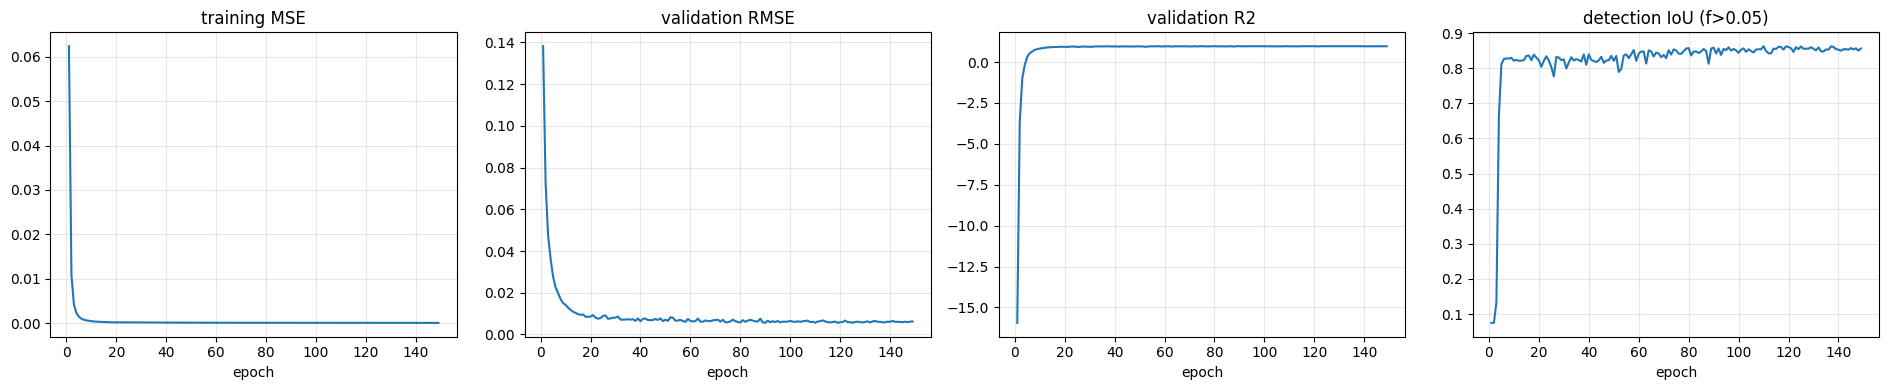

In [10]:
ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 4, figsize=(19, 4))
ax[0].plot(ep, history["train_loss"]); ax[0].set_title("training MSE"); ax[0].set_xlabel("epoch"); ax[0].grid(alpha=0.3)
ax[1].plot(ep, history["val_rmse"]); ax[1].set_title("validation RMSE"); ax[1].set_xlabel("epoch"); ax[1].grid(alpha=0.3)
ax[2].plot(ep, history["val_r2"]); ax[2].set_title("validation R2"); ax[2].set_xlabel("epoch"); ax[2].grid(alpha=0.3)
ax[3].plot(ep, history["val_iou"]); ax[3].set_title("detection IoU (f>0.05)"); ax[3].set_xlabel("epoch"); ax[3].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG+"/training_curves.png", dpi=150, bbox_inches="tight"); plt.show()


## 6. Evaluation (held-out test set)

### 6.1 Regression accuracy

RMSE 0.0056 | MAE 0.0019 | detection IoU 0.865
over ice-bearing pixels: RMSE 0.0152 | R2 0.923


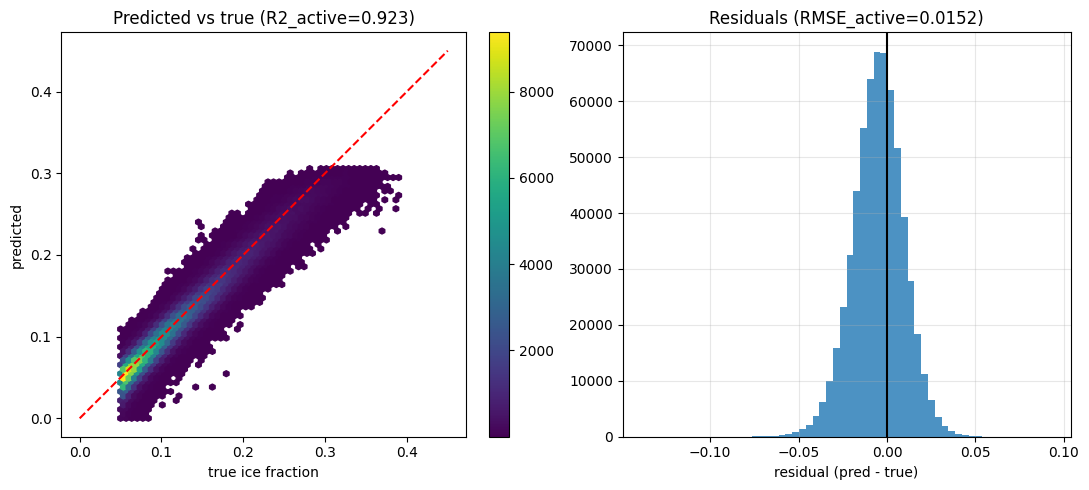

In [11]:
prob_te = predict(model, Xte_n, DEVICE, tcfg.batch_size)
m = regression_metrics(prob_te, Yte)
print("RMSE %.4f | MAE %.4f | detection IoU %.3f" % (m["rmse"], m["mae"], m["detect_iou"]))
print("over ice-bearing pixels: RMSE %.4f | R2 %.3f" % (m.get("rmse_active", float('nan')), m.get("r2_active", float('nan'))))

# predicted vs true ice fraction (ice-bearing pixels)
pt = prob_te.ravel(); tt = Yte.ravel(); act = tt >= 0.05
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
hb = ax[0].hexbin(tt[act], pt[act], gridsize=50, cmap="viridis", mincnt=1)
ax[0].plot([0, 0.45], [0, 0.45], "r--"); ax[0].set_xlabel("true ice fraction"); ax[0].set_ylabel("predicted")
ax[0].set_title("Predicted vs true (R2_active=%.3f)" % m.get("r2_active", float('nan'))); plt.colorbar(hb, ax=ax[0], fraction=0.046)
res = pt[act] - tt[act]
ax[1].hist(res, bins=60, color="tab:blue", alpha=0.8); ax[1].axvline(0, c="k")
ax[1].set_xlabel("residual (pred - true)"); ax[1].set_title("Residuals (RMSE_active=%.4f)" % m.get("rmse_active", float('nan'))); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG+"/regression_accuracy.png", dpi=150, bbox_inches="tight"); plt.show()


### 6.2 Detection performance (ice present vs absent) and baseline

detection IoU      | deterministic CPR/DOP 0.031 | regressor 0.865
detection F1       | deterministic 0.061 | regressor 0.927
detection accuracy | deterministic 0.9264 | regressor 0.9892
detection ROC-AUC  | regressor 0.9986 | PR-AUC 0.9847


h:\Hobby Projrctrs\isro ic dtection\src\evaluation.py:66: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
h:\Hobby Projrctrs\isro ic dtection\src\evaluation.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(path, dpi=150, bbox_inches="tight")
C:\workspace\yes-scan-apex\yes_scan_prototype\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


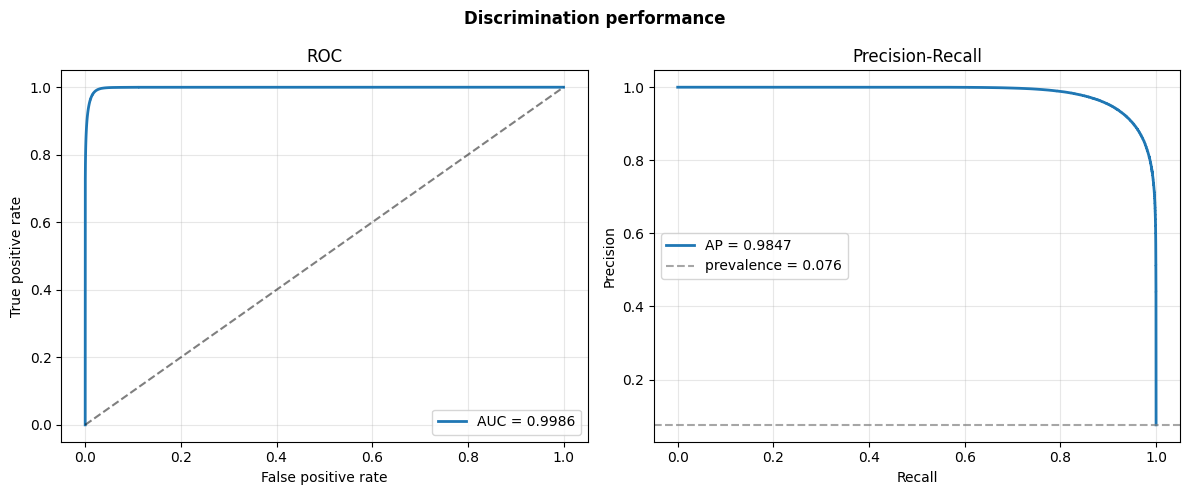

In [12]:
y_det = (Yte >= 0.05).astype(np.uint8)
base_mask = ice_threshold_mask(Xte[:, 0], Xte[:, 1]).astype(np.float32)
from src.train import pixel_metrics
base = pixel_metrics(base_mask, y_det, thr=0.5)
cnn_det = pixel_metrics(prob_te, y_det, thr=0.05)
print("detection IoU      | deterministic CPR/DOP %.3f | regressor %.3f" % (base["iou"], cnn_det["iou"]))
print("detection F1       | deterministic %.3f | regressor %.3f" % (base["f1"], cnn_det["f1"]))
print("detection accuracy | deterministic %.4f | regressor %.4f" % (base["accuracy"], cnn_det["accuracy"]))
print("detection ROC-AUC  | regressor %.4f | PR-AUC %.4f"
      % (cnn_det.get("roc_auc", float('nan')), cnn_det.get("pr_auc", float('nan'))))
ev.plot_roc_pr(y_det, prob_te, save=FIG+"/roc_pr.png"); plt.show()


### 6.3 Per-scene accuracy and bootstrap CI

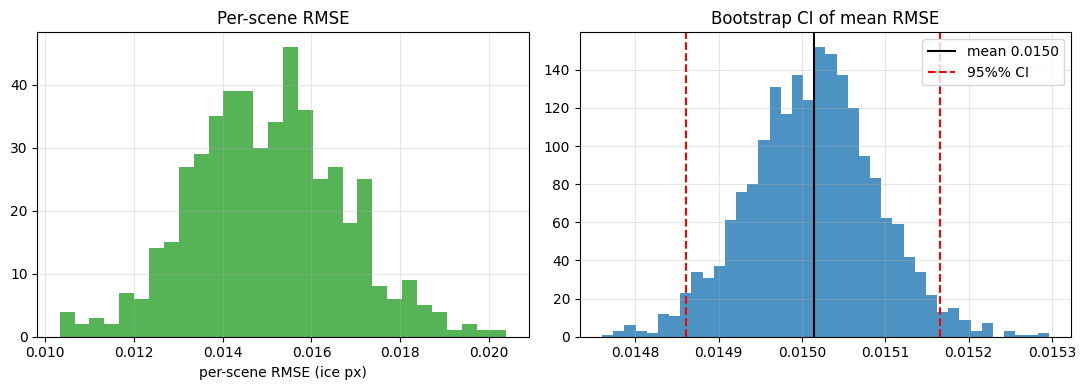

mean per-scene RMSE 0.0150 | 95% CI [0.0149, 0.0152]


In [13]:
per = []
for i in range(len(Xte)):
    pi = predict(model, Xte_n[i:i+1], DEVICE)[0]
    mi = regression_metrics(pi, Yte[i])
    per.append(mi.get("rmse_active", np.nan))
per = np.array([v for v in per if np.isfinite(v)])
rng = np.random.default_rng(0)
boot = [rng.choice(per, len(per), replace=True).mean() for _ in range(2000)]
lo, hi = np.percentile(boot, [2.5, 97.5])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(per, bins=30, color="tab:green", alpha=0.8); ax[0].set_xlabel("per-scene RMSE (ice px)"); ax[0].set_title("Per-scene RMSE"); ax[0].grid(alpha=0.3)
ax[1].hist(boot, bins=40, color="tab:blue", alpha=0.8); ax[1].axvline(per.mean(), c="k", label="mean %.4f"%per.mean()); ax[1].axvline(lo, c="r", ls="--"); ax[1].axvline(hi, c="r", ls="--", label="95%% CI")
ax[1].set_title("Bootstrap CI of mean RMSE"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG+"/per_scene_ci.png", dpi=150, bbox_inches="tight"); plt.show()
print("mean per-scene RMSE %.4f | 95%% CI [%.4f, %.4f]" % (per.mean(), lo, hi))


### 6.4 Qualitative examples

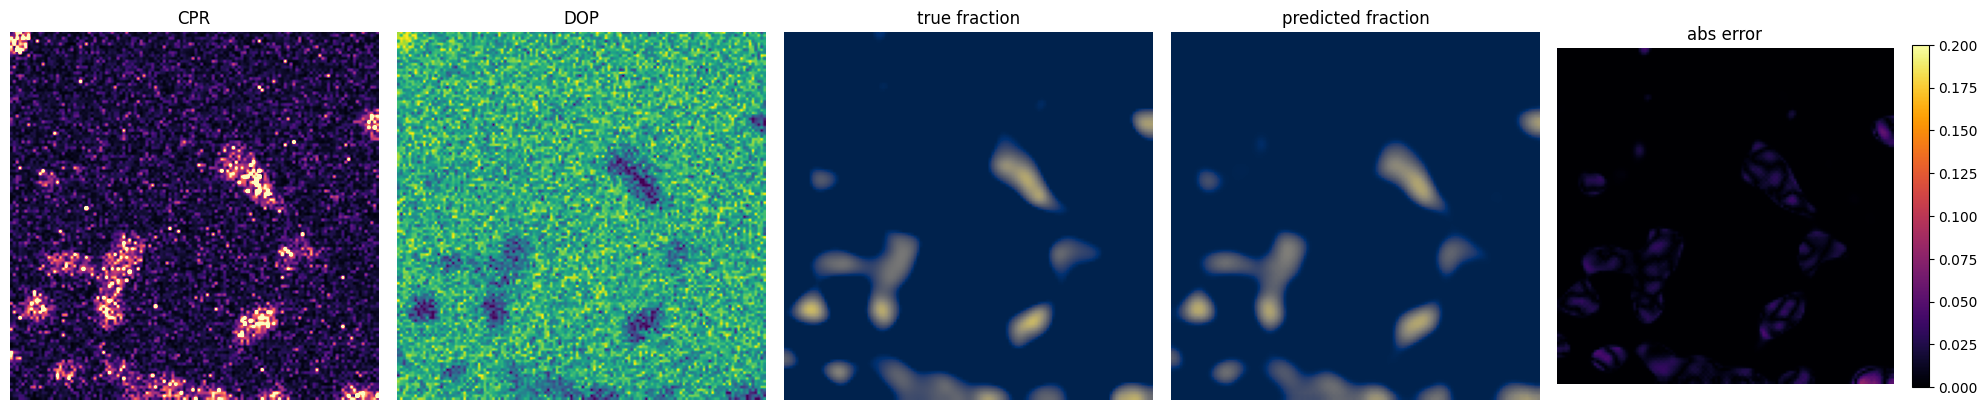

In [14]:
k = int(np.argmax([Yte[i].mean() for i in range(len(Yte))]))
xs, ft = Xte[k], Yte[k]
pr = predict(model, norm.transform(xs[None]), DEVICE)[0]
fig, ax = plt.subplots(1, 5, figsize=(20, 4))
ax[0].imshow(xs[0], cmap="magma", vmin=0, vmax=2); ax[0].set_title("CPR"); ax[0].axis("off")
ax[1].imshow(xs[1], cmap="viridis", vmin=0, vmax=1); ax[1].set_title("DOP"); ax[1].axis("off")
ax[2].imshow(ft, cmap="cividis", vmin=0, vmax=0.4); ax[2].set_title("true fraction"); ax[2].axis("off")
ax[3].imshow(pr, cmap="cividis", vmin=0, vmax=0.4); ax[3].set_title("predicted fraction"); ax[3].axis("off")
im = ax[4].imshow(np.abs(pr-ft), cmap="inferno", vmin=0, vmax=0.2); ax[4].set_title("abs error"); ax[4].axis("off"); plt.colorbar(im, ax=ax[4], fraction=0.046)
plt.tight_layout(); plt.savefig(FIG+"/qualitative.png", dpi=150, bbox_inches="tight"); plt.show()


### 6.5 Detection confusion matrix and extended metric table
The regressor doubles as a detector (ice present where fraction >= 0.05). The
confusion matrix and the extended metric table (MCC, Cohen's kappa, specificity,
expected calibration error) benchmark it against the deterministic CPR/DOP rule.

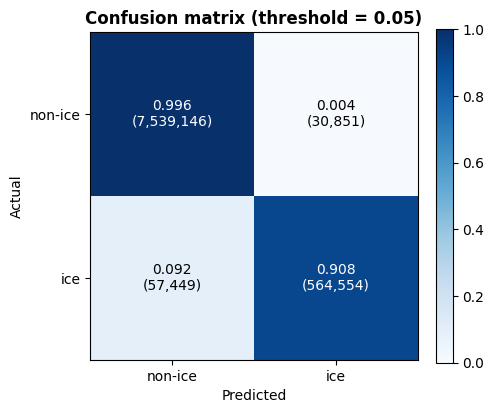

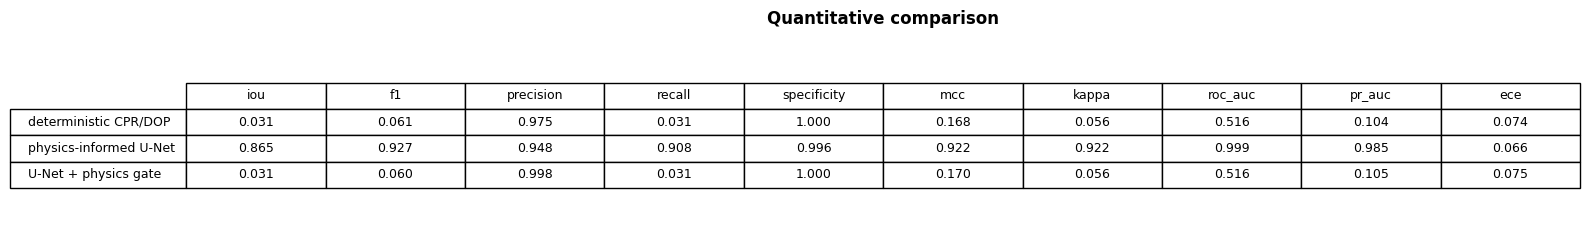

deterministic CPR/DOP    IoU 0.031 F1 0.061 spec 1.000 MCC 0.168 kappa 0.056 ECE 0.074
physics-informed U-Net   IoU 0.865 F1 0.927 spec 0.996 MCC 0.922 kappa 0.922 ECE 0.066
U-Net + physics gate     IoU 0.031 F1 0.060 spec 1.000 MCC 0.170 kappa 0.056 ECE 0.075


In [15]:
from src.evaluation import extended_metrics
ev.plot_confusion(y_det, prob_te, thr=0.05, save=FIG+"/confusion.png"); plt.show()
prob_te_gated = physics_gate(prob_te, Xte[:, 0], Xte[:, 1])
rows = {
    "deterministic CPR/DOP": extended_metrics(y_det, base_mask, 0.5),
    "physics-informed U-Net": extended_metrics(y_det, prob_te, 0.05),
    "U-Net + physics gate": extended_metrics(y_det, prob_te_gated, 0.05),
}
ev.plot_metric_table(rows, save=FIG+"/metric_table.png"); plt.show()
for name, r in rows.items():
    print("%-24s IoU %.3f F1 %.3f spec %.3f MCC %.3f kappa %.3f ECE %.3f"
          % (name, r.get("iou", float('nan')), r.get("f1", float('nan')),
             r.get("specificity", float('nan')), r.get("mcc", float('nan')),
             r.get("kappa", float('nan')), r.get("ece", float('nan'))))


### 6.6 Detection-threshold sensitivity
IoU / F1 / precision / recall as the detection threshold on predicted ice
fraction is swept, confirming the operating point is stable, not cherry-picked.

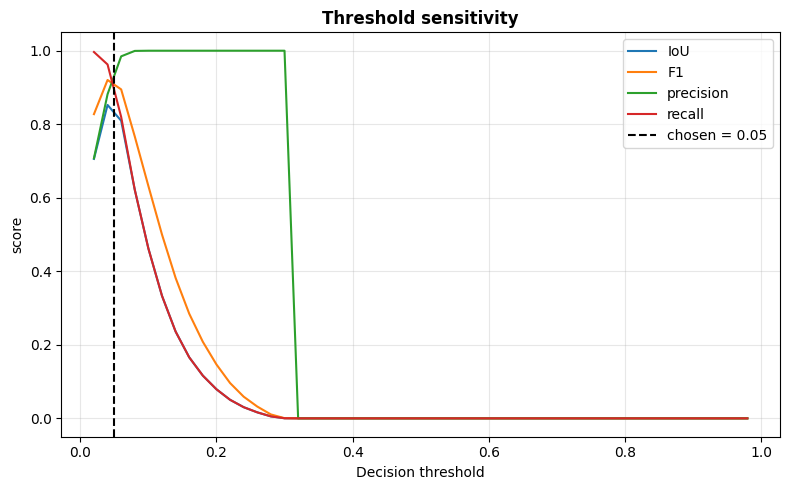

In [16]:
ev.plot_threshold_sweep(y_det, prob_te, chosen=0.05, save=FIG+"/threshold_sweep.png"); plt.show()


### 6.7 Reliability and score separation
How the predicted ice fraction relates to the observed frequency of ice-bearing
pixels, and how well the score separates ice from non-ice.

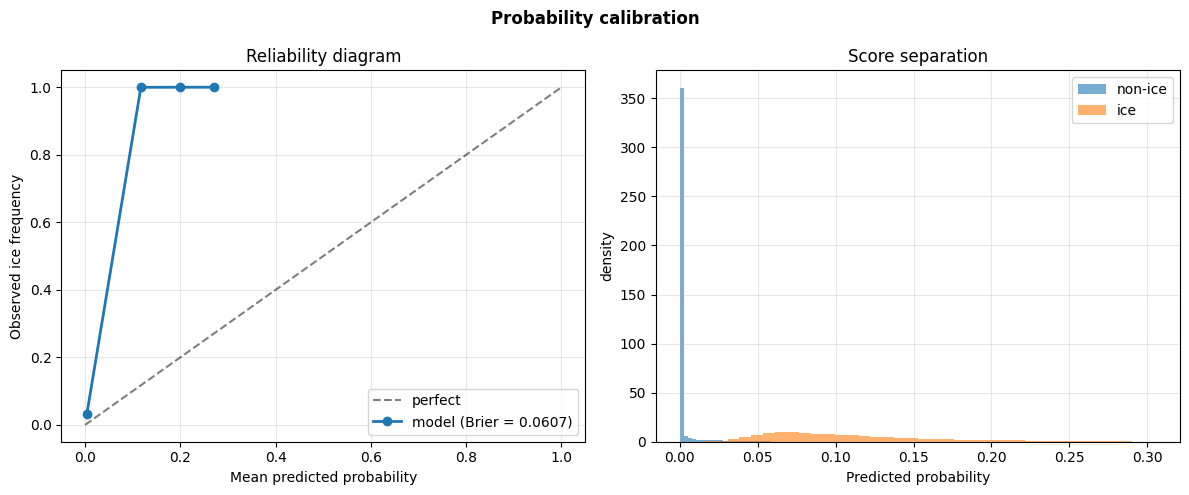

In [17]:
ev.plot_calibration(y_det, prob_te, save=FIG+"/calibration.png"); plt.show()


### 6.8 Learned ice-fraction response surface
The model is probed with constant (CPR, DOP) inputs to recover the response
surface it learned. A physically valid estimator should increase with CPR and
concentrate signal inside the CPR>1 / DOP<0.13 ice region (green box).

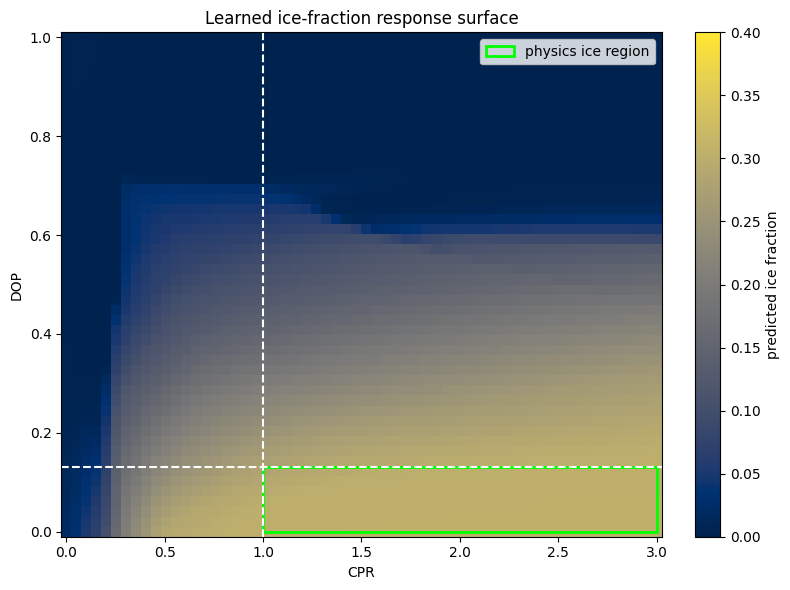

In [18]:
cprs = np.linspace(0.0, 3.0, 60); dops = np.linspace(0.0, 1.0, 50)
probe = np.zeros((len(cprs)*len(dops), 2, 32, 32), dtype=np.float32)
k = 0
for c in cprs:
    for d in dops:
        probe[k, 0] = c; probe[k, 1] = d; k += 1
surf = predict(model, norm.transform(probe), DEVICE)[:, 16, 16].reshape(len(cprs), len(dops)).T
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(cprs, dops, surf, cmap="cividis", vmin=0, vmax=0.4, shading="auto")
ax.axvline(1.0, ls="--", c="w"); ax.axhline(0.13, ls="--", c="w")
ax.add_patch(plt.Rectangle((1.0, 0.0), 2.0, 0.13, fill=False, edgecolor="lime", lw=2, label="physics ice region"))
ax.set_xlabel("CPR"); ax.set_ylabel("DOP"); ax.set_title("Learned ice-fraction response surface")
ax.legend(loc="upper right"); plt.colorbar(im, ax=ax, fraction=0.046, label="predicted ice fraction")
plt.tight_layout(); plt.savefig(FIG+"/response_surface.png", dpi=150, bbox_inches="tight"); plt.show()


### 6.9 Input saliency
Input-gradient saliency shows which channel (CPR vs DOP) and which regions drive
the estimate, a transparency check that the model uses physically sensible cues.

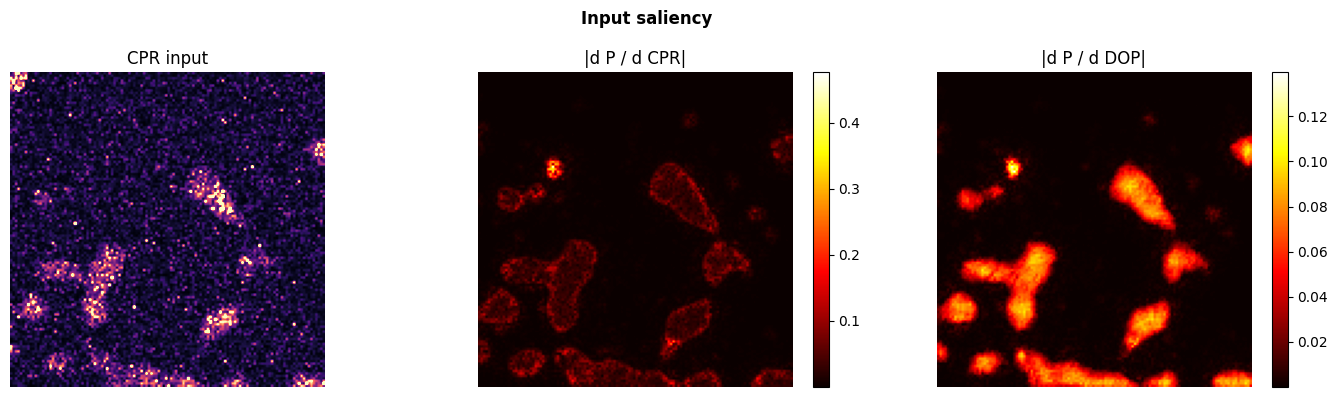

In [19]:
sal_idx = int(np.argmax([Yte[i].mean() for i in range(len(Yte))]))
ev.plot_saliency(model, norm, Xte[sal_idx], DEVICE, save=FIG+"/saliency.png"); plt.show()


## 7. Model export

In [20]:
ckpt = {"state_dict": model.state_dict(), "in_ch": 2, "base_width": tcfg.base_width,
        "depth": tcfg.depth, "dropout": tcfg.dropout, "task": "ice_fraction_regression",
        "normalizer": norm.state()}
torch.save(ckpt, "models/ice_unet_v3.pt")
with open("models/metrics_v3.json", "w") as f:
    json.dump({"regression": m, "detection_baseline": base, "detection_cnn": cnn_det,
               "best_val_rmse": float(best_rmse)}, f, indent=2)
with open("models/history_v3.json", "w") as f:
    json.dump(history, f)
print("saved models/ice_unet_v3.pt, metrics_v3.json, history_v3.json")


saved models/ice_unet_v3.pt, metrics_v3.json, history_v3.json


## 8. Ice volume estimation with uncertainty (synthetic demonstration)

The predicted ice-fraction map is integrated over area and L-band sensing depth.
Monte-Carlo sampling of the dielectric parameters, sensing depth, and the model's
own RMSE yields a 95% confidence interval on total water-ice volume.

In [21]:
demo_frac = predict(model, Xte_n[:1], DEVICE)[0]
PIX = 30.0 * 30.0   # nominal multilooked ground-pixel area (m^2)
vol = di.monte_carlo_volume(demo_frac, pixel_area_m2=PIX, depth_m=SENSING_DEPTH_M,
                            f_ice_rmse=m.get("rmse_active", 0.05), n_samples=4000)
print("scene ice volume: mean %.3e m3 | 95%% CI [%.3e, %.3e] | mass %.3e kg"
      % (vol["mean_m3"], vol["ci95_lo_m3"], vol["ci95_hi_m3"], vol["mean_mass_kg"]))


scene ice volume: mean 6.344e+04 m3 | 95% CI [2.633e+04, 1.031e+05] | mass 5.817e+07 kg


## 9. Application to the real Haworth-crater DFSAR strip

In [22]:
zips = sorted(glob.glob("data/raw/dfsar/*.zip"))
assert zips, "No DFSAR products in data/raw/dfsar/."
# Scene that crosses Haworth (verified by geometry):
SCENE_ZIP = next((z for z in zips if "20251026t125618324" in z), zips[0])
LOOKS = 9
tp = gc.load_tiepoints(SCENE_ZIP)
paths = find_compact_slc_in_zip(SCENE_ZIP)
with rasterio.open(paths["lh"]) as ds:
    H, W = ds.height, ds.width

# Azimuth window where tie points fall inside the Haworth box.
LAT, LON = tp["LAT"], tp["LON"]
az_idx = np.linspace(0, H - 1, tp["naz"])
inbox_lines = np.where(np.any((LAT >= HAWORTH["lat"][0]) & (LAT <= HAWORTH["lat"][1]) &
                              (LON >= HAWORTH["lon"][0]) & (LON <= HAWORTH["lon"][1]), axis=1))[0]
if len(inbox_lines):
    a0 = int(az_idx[inbox_lines.min()]); a1 = int(az_idx[inbox_lines.max()])
    pad = 4000
    AZ_START = max(0, a0 - pad); AZ_LEN = min(H - AZ_START, (a1 - a0) + 2 * pad)
else:
    AZ_START, AZ_LEN = max(0, H//2 - 30000), 60000
print("scene:", os.path.basename(SCENE_ZIP), "| Haworth azimuth window:", AZ_START, "-", AZ_START + AZ_LEN)


scene: ch2_sar_ncxl_20251026t125618324_d_cp_d18.zip | Haworth azimuth window: 17790 - 77497


### 9.1 CPR / DOP / m-chi over Haworth

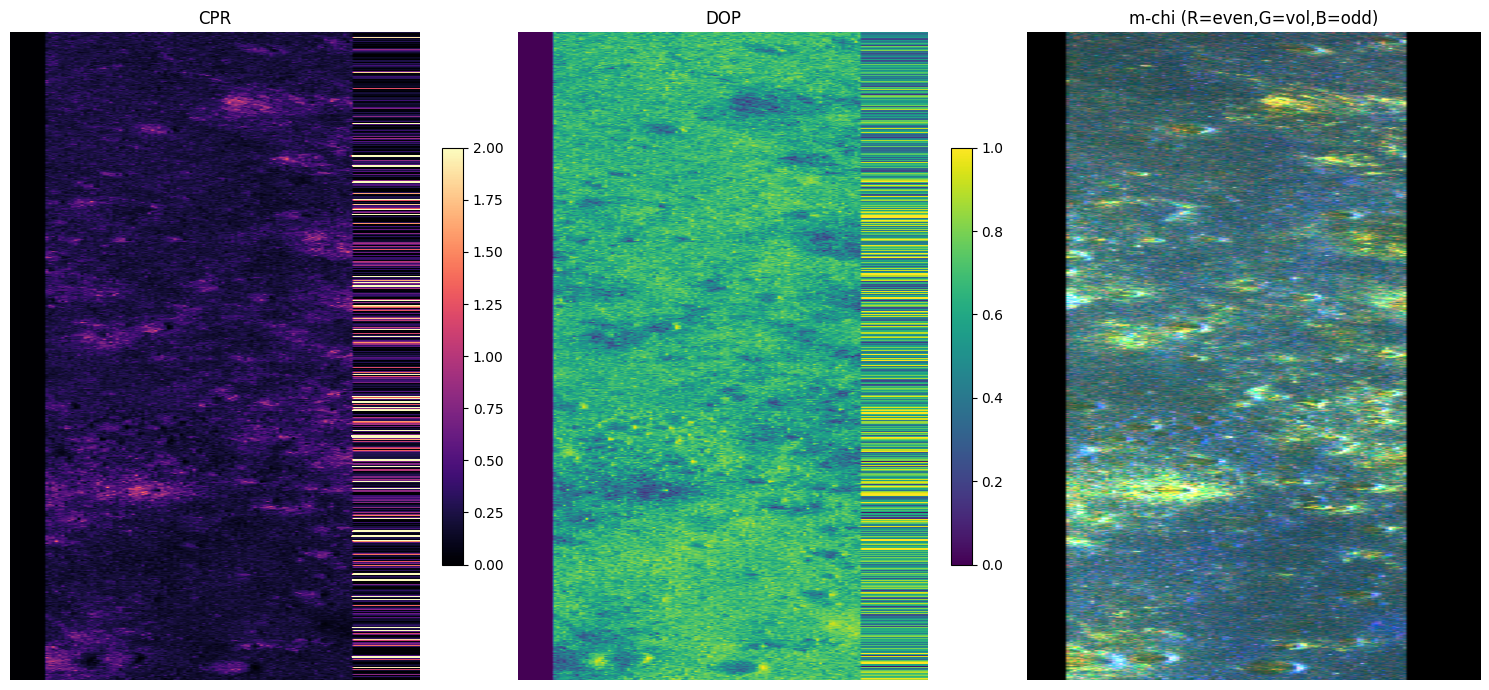

CPR median 0.220 | DOP median 0.619 | pixels CPR>1 2.41%


In [23]:
real = dfsar_compact_features(SCENE_ZIP, az_start=AZ_START, az_len=AZ_LEN, looks=LOOKS)
cpr_r, dop_r, feat = real["cpr"], real["dop"], real["feat"]
win = Window(0, AZ_START, W, AZ_LEN)
e_h = read_complex_band(paths["lh"], window=win); e_v = read_complex_band(paths["lv"], window=win)
s1, s2, s3, s4 = stokes_from_compact(e_h, e_v, looks=LOOKS)
rgb = mchi_decomposition(s1[::LOOKS, ::LOOKS], s2[::LOOKS, ::LOOKS], s3[::LOOKS, ::LOOKS], s4[::LOOKS, ::LOOKS])
def sq(a, mx=1000): return a[::max(1, a.shape[0]//mx)]
fig, ax = plt.subplots(1, 3, figsize=(15, 7))
im0 = ax[0].imshow(sq(cpr_r), cmap="magma", vmin=0, vmax=2, aspect="auto"); ax[0].set_title("CPR"); ax[0].axis("off"); plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(sq(dop_r), cmap="viridis", vmin=0, vmax=1, aspect="auto"); ax[1].set_title("DOP"); ax[1].axis("off"); plt.colorbar(im1, ax=ax[1], fraction=0.046)
ax[2].imshow(sq(rgb), aspect="auto"); ax[2].set_title("m-chi (R=even,G=vol,B=odd)"); ax[2].axis("off")
plt.tight_layout(); plt.savefig(FIG+"/haworth_polarimetry.png", dpi=150, bbox_inches="tight"); plt.show()
print("CPR median %.3f | DOP median %.3f | pixels CPR>1 %.2f%%" % (np.median(cpr_r), np.median(dop_r), 100*np.mean(cpr_r>1)))


### 9.2 Stage 1 - Ice detection (the gate)
Ice is declared only where two independent criteria agree (a conservative
AND-gate): the physics admissibility test (CPR>1 and DOP<0.13) and the learned
detector (predicted ice fraction >= 0.05). Every downstream product -
concentration, size, and volume - is computed only inside this gate.

physics-admissible pixels : 0.42%
model-detected pixels     : 9.84%
GATED ice detections      : 0.17% (1406 pixels)


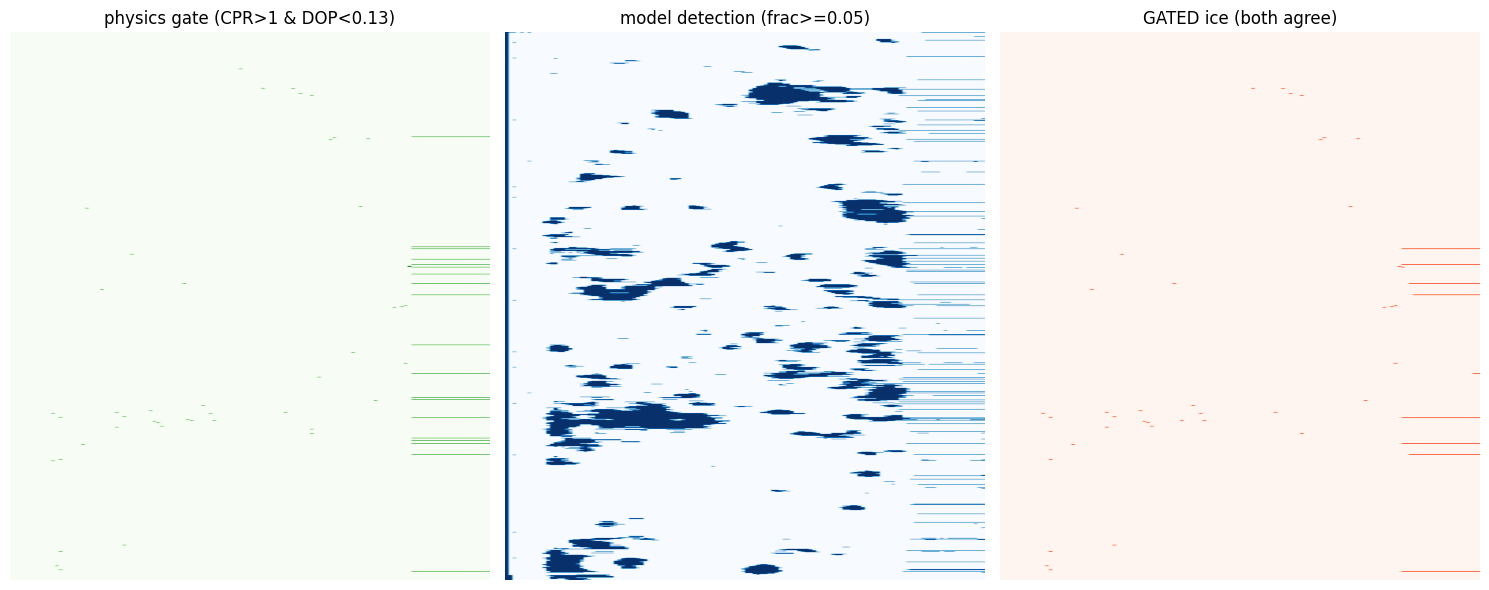

In [24]:
# STAGE 1: DETECT. Ice only where BOTH agree (conservative AND-gate):
#   (a) physics admissibility : CPR > 1.0 AND DOP < 0.13
#   (b) learned detector      : predicted ice fraction >= 0.05
frac_map  = predict_scene(model, norm, feat, DEVICE, tile=128, overlap=24)
phys_mask  = ice_threshold_mask(cpr_r, dop_r)
model_mask = frac_map >= 0.05
ice_mask   = phys_mask & model_mask          # <-- the gate used by all later stages

print("physics-admissible pixels : %.2f%%" % (100*phys_mask.mean()))
print("model-detected pixels     : %.2f%%" % (100*model_mask.mean()))
print("GATED ice detections      : %.2f%% (%d pixels)" % (100*ice_mask.mean(), int(ice_mask.sum())))

def sq(a, mx=1000): return a[::max(1, a.shape[0]//mx)]
fig, ax = plt.subplots(1, 3, figsize=(15, 6))
ax[0].imshow(sq(phys_mask.astype(float)), cmap="Greens", aspect="auto"); ax[0].set_title("physics gate (CPR>1 & DOP<0.13)"); ax[0].axis("off")
ax[1].imshow(sq(model_mask.astype(float)), cmap="Blues", aspect="auto"); ax[1].set_title("model detection (frac>=0.05)"); ax[1].axis("off")
ax[2].imshow(sq(ice_mask.astype(float)), cmap="Reds", aspect="auto"); ax[2].set_title("GATED ice (both agree)"); ax[2].axis("off")
plt.tight_layout(); plt.savefig(FIG+"/haworth_detection_gate.png", dpi=150, bbox_inches="tight"); plt.show()


### 9.3 Stage 2 - Concentration, size, and volume (gated)
Only the gated ice pixels are quantified. Concentration is the mean predicted
ice fraction; size is the geocoded detected area (km^2) and per-patch extent;
volume integrates the gated fraction over area and L-band sensing depth, with a
95% Monte-Carlo confidence interval.

Haworth window lat [-87.886, -87.020] lon [-7.274, 1.836]
DETECTED ice SIZE   : 0.748 km^2 in 141 patch(es) | largest 0.092 km^2
mean CONCENTRATION  : 0.048 (ice fraction over detected pixels)
ESTIMATED VOLUME (top 2.0 m): 1.641e+04 m3 | 95% CI [0.000e+00, 4.538e+04] | mass ~1.505e+07 kg


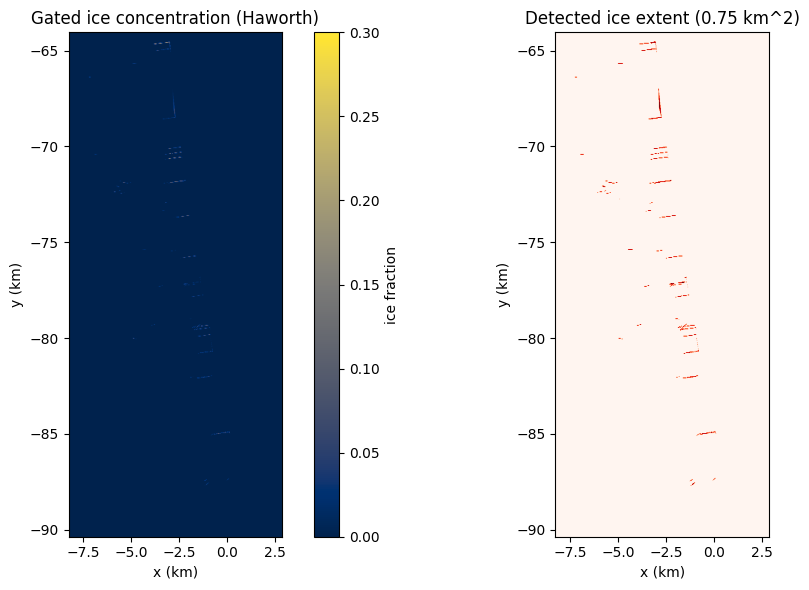

In [25]:
# STAGE 2: QUANTIFY, only inside the detection gate.
frac_gated = np.where(ice_mask, frac_map, 0.0)

# Geocode the gated ice-fraction map to polar-stereographic metres.
geo = gc.geocode_window(tp, frac_gated, AZ_START, AZ_LEN, LOOKS, H, W, out_px=700)
ex = geo["polar_extent"]
area_per_px = abs((ex[1]-ex[0])/700.0) * abs((ex[3]-ex[2])/700.0)   # m^2 per geocoded pixel
gmap = np.where(np.isfinite(geo["raster"]), geo["raster"], 0.0)
det = gmap > 0.0

# SIZE: detected ice extent and patch statistics.
from scipy import ndimage
lbl, n_patch = ndimage.label(det)
patch_px = ndimage.sum(np.ones_like(det, dtype=float), lbl, index=np.arange(1, n_patch + 1)) if n_patch else np.array([])
detected_area_km2 = det.sum() * area_per_px / 1e6
largest_km2 = (patch_px.max() * area_per_px / 1e6) if patch_px.size else 0.0

# CONCENTRATION: mean ice fraction over detected pixels.
mean_conc = float(gmap[det].mean()) if det.any() else 0.0

# VOLUME: integrate gated fraction over area and sensing depth, with 95% CI.
vol = di.monte_carlo_volume(gmap, pixel_area_m2=area_per_px, depth_m=SENSING_DEPTH_M,
                            f_ice_rmse=m.get("rmse_active", 0.05), n_samples=4000)
la0, la1, lo0, lo1 = geo["latlon_bbox"]
print("Haworth window lat [%.3f, %.3f] lon [%.3f, %.3f]" % (la0, la1, lo0, lo1))
print("DETECTED ice SIZE   : %.3f km^2 in %d patch(es) | largest %.3f km^2"
      % (detected_area_km2, n_patch, largest_km2))
print("mean CONCENTRATION  : %.3f (ice fraction over detected pixels)" % mean_conc)
print("ESTIMATED VOLUME (top %.1f m): %.3e m3 | 95%% CI [%.3e, %.3e] | mass ~%.3e kg"
      % (SENSING_DEPTH_M, vol["mean_m3"], vol["ci95_lo_m3"], vol["ci95_hi_m3"], vol["mean_mass_kg"]))
gc.save_polar_geotiff("outputs/v3_ice_fraction_geocoded.tif", gmap, ex)

fig, ax = plt.subplots(1, 2, figsize=(13, 6))
im = ax[0].imshow(gmap, cmap="cividis", vmin=0, vmax=0.3, origin="lower",
                  extent=[ex[0]/1000, ex[1]/1000, ex[2]/1000, ex[3]/1000])
ax[0].set_title("Gated ice concentration (Haworth)"); ax[0].set_xlabel("x (km)"); ax[0].set_ylabel("y (km)")
plt.colorbar(im, ax=ax[0], fraction=0.046, label="ice fraction")
ax[1].imshow(det, cmap="Reds", origin="lower",
             extent=[ex[0]/1000, ex[1]/1000, ex[2]/1000, ex[3]/1000])
ax[1].set_title("Detected ice extent (%.2f km^2)" % detected_area_km2); ax[1].set_xlabel("x (km)"); ax[1].set_ylabel("y (km)")
plt.tight_layout(); plt.savefig(FIG+"/haworth_gated_quantification.png", dpi=150, bbox_inches="tight"); plt.show()


### 9.4 Real Haworth scene in CPR-DOP feature space
Where the real Haworth pixels fall in CPR-DOP space, and which pixels the model
flags as ice relative to the physical ice region (green box). This is the
real-data analogue of the learned response surface in Section 6.8.

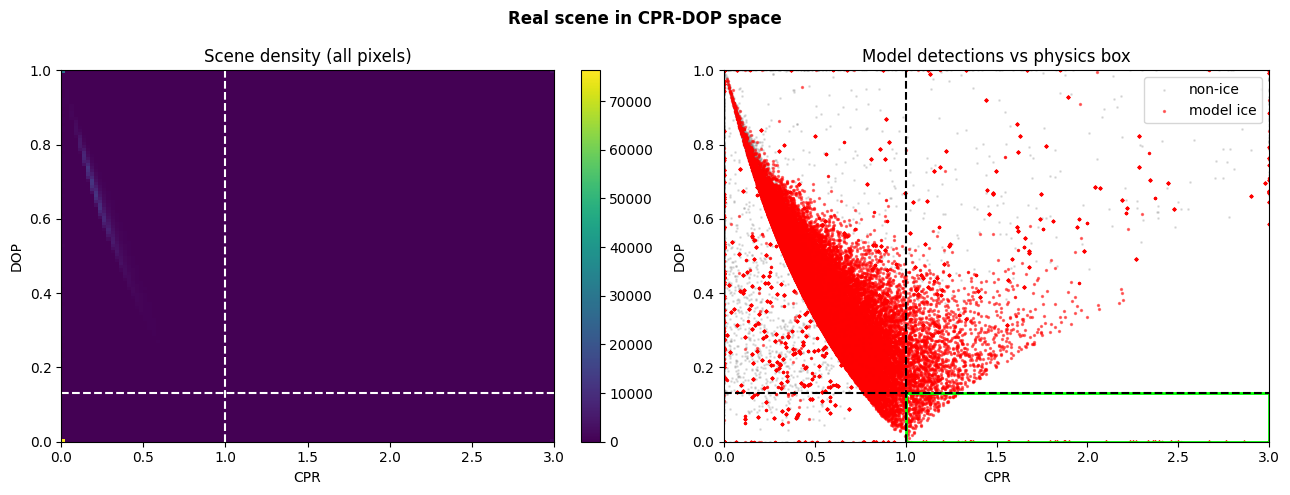

In [26]:
ev.plot_real_cpr_dop_density(cpr_r, dop_r, frac_map, thr=0.05,
                             save=FIG+"/haworth_cpr_dop_density.png"); plt.show()


### 9.5 Incidence-angle dependence (real scene)
A genuine ice signature should not be an artefact of viewing geometry. Median
CPR, DOP, and predicted ice fraction are shown against radar incidence angle;
flat trends indicate the detection is not incidence-driven.

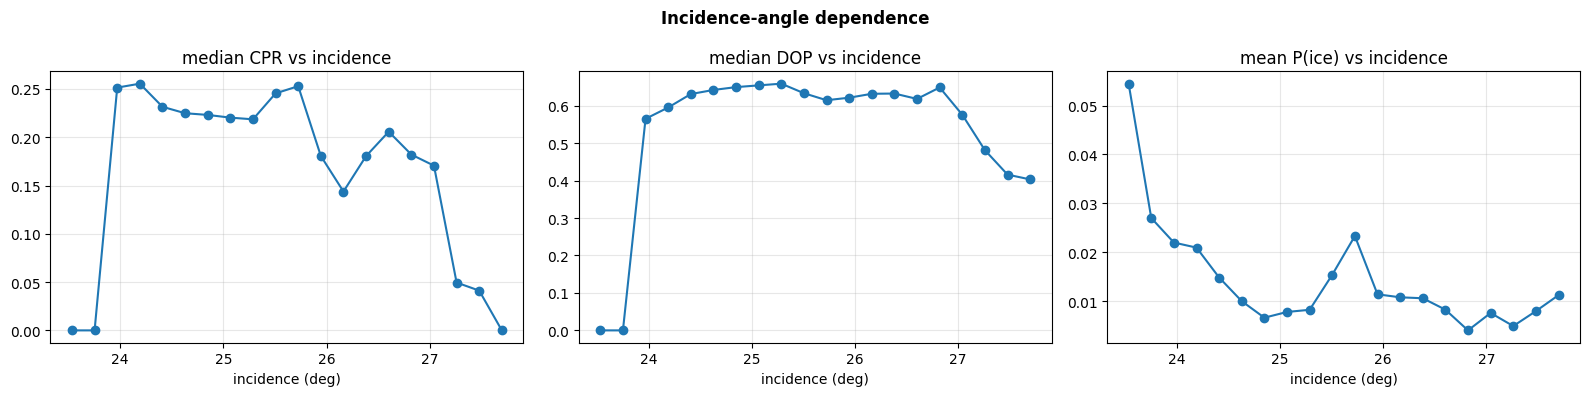

In [27]:
sc = gc.sample_at_tiepoints(tp, cpr_r,   AZ_START, AZ_LEN, LOOKS, H, W)
sd = gc.sample_at_tiepoints(tp, dop_r,   AZ_START, AZ_LEN, LOOKS, H, W)
sp = gc.sample_at_tiepoints(tp, frac_map, AZ_START, AZ_LEN, LOOKS, H, W)
ev.plot_incidence_dependence(sc["inc"], sc["val"], sd["val"], sp["val"],
                             save=FIG+"/haworth_incidence.png"); plt.show()


## 10. Independent corroboration

A radar ice estimate is only credible if independent evidence agrees. Two
complementary cross-checks are applied:

- **ISRO-only, internal:** the deterministic CPR>1 / DOP<0.13 ice-signature
  fraction inside the Haworth permanently-shadowed window is compared, across
  multiple independent DFSAR passes, against an incidence-angle-matched control
  window. Cross-pass agreement is the strongest claim radar alone can make.
- **NASA LRO context:** the same Haworth box is checked against LRO Diviner
  annual maximum temperature (water-ice thermal stability, T_max < 110 K) and
  LRO LEND water-equivalent hydrogen. Using LRO products as independent context
  is standard in lunar-ice work and referenced by the problem statement; DFSAR
  remains the primary ISRO instrument. Gridded products in
  `data/corroboration/` are used if present, otherwise published cold-trap
  reference values (cited) are used so the notebook runs without downloads.

### 10.1 Internal cross-pass + incidence-matched control test (ISRO data only)

independent passes: ['ch2_sar_ncxl_20251026t125618324_d_cp_d18.zip', 'ch2_sar_ncxl_20251026t224558634_d_cp_d18.zip']

pass                                           Haworth%   control%    enrich   p-value  inc(deg)
ch2_sar_ncxl_20251026t125618324_d_cp_d18.zip    0.5187%    0.2827% x   1.83   4.5e-32      25.0
ch2_sar_ncxl_20251026t224558634_d_cp_d18.zip    0.0778%    0.1240% x   0.63   4.4e-06      25.6

1 of 2 independent passes show significant Haworth enrichment (p<1e-3).
cross-pass reproducible: False


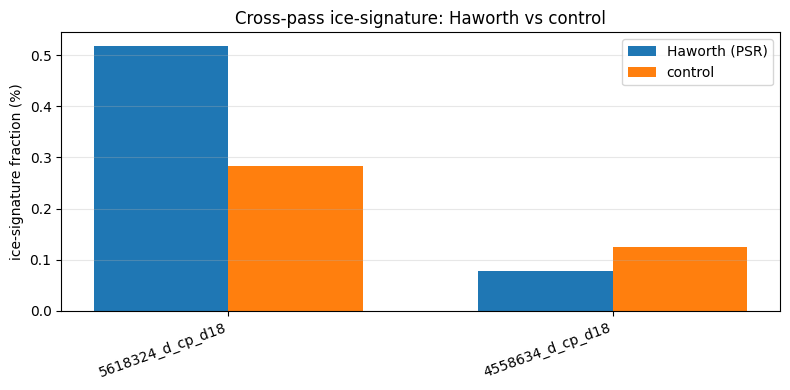

In [28]:
from src import corroboration as corr

# Independent passes that cross Haworth (different acquisition dates/orbits).
haworth_passes = [z for z in zips
                  if ("20251026t125618324" in z or "20251026t224558634" in z)]
if len(haworth_passes) < 2:
    haworth_passes = zips[:2]
print("independent passes:", [os.path.basename(z) for z in haworth_passes])

cp = corr.cross_pass_control_test(haworth_passes, HAWORTH, looks=LOOKS)
print("\n%-44s %10s %10s %9s %9s %9s" %
      ("pass", "Haworth%", "control%", "enrich", "p-value", "inc(deg)"))
for r in cp["records"]:
    print("%-44s %9.4f%% %9.4f%% x%7.2f %9.1e %9.1f" %
          (r["pass"][:44], 100*r["haworth_fraction"], 100*r["control_fraction"],
           r["enrichment"], r["p_value"], r["haworth_inc_deg"]))
v = cp["verdict"]
print("\n%d of %d independent passes show significant Haworth enrichment (p<1e-3)."
      % (v["n_enriched_significant"], v["n_passes"]))
print("cross-pass reproducible:", v["reproducible"])

labels = [r["pass"][-20:-4] for r in cp["records"]]
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(cp["records"])); w = 0.35
ax.bar(x - w/2, [100*r["haworth_fraction"] for r in cp["records"]], w, label="Haworth (PSR)")
ax.bar(x + w/2, [100*r["control_fraction"] for r in cp["records"]], w, label="control")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("ice-signature fraction (%)"); ax.set_title("Cross-pass ice-signature: Haworth vs control")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig(FIG+"/cross_pass_control.png", dpi=150, bbox_inches="tight"); plt.show()


### 10.2 NASA LRO context: Diviner thermal stability + LEND hydrogen

nearest cold trap     : Haworth
data source           : published reference (Paige et al. 2010 (LRO Diviner cold traps); Sanin et al. 2017 (LRO LEND water-equivalent hydrogen))
Diviner T_max         : 88.0 K   (ice stable if < 110 K)  -> stable: True
LEND WEH              : 1.00 wt% (elevated if >= 0.5 wt%) -> enriched: True
NASA context consistent: True
citation              : Paige et al. 2010 (LRO Diviner cold traps); Sanin et al. 2017 (LRO LEND water-equivalent hydrogen)


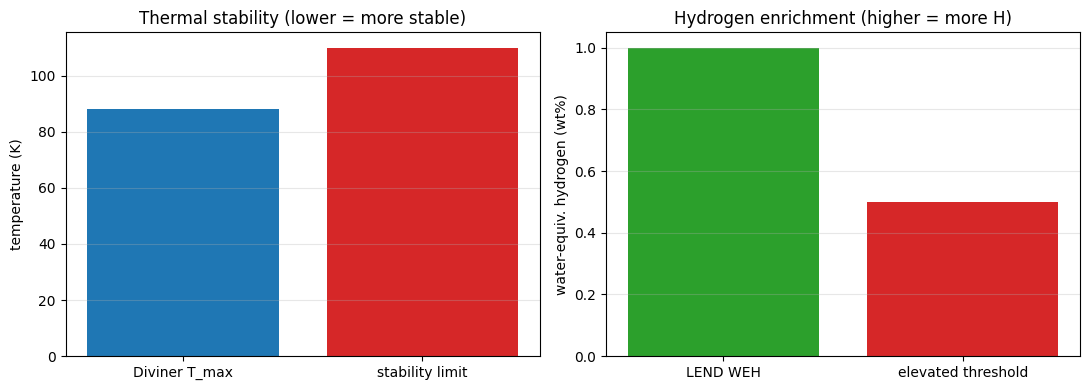

In [29]:
la0, la1, lo0, lo1 = geo["latlon_bbox"]
nasa = corr.nasa_context_check((la0, la1), (lo0, lo1))
print("nearest cold trap     :", nasa["nearest_cold_trap"])
print("data source           :", nasa["source"])
print("Diviner T_max         : %.1f K   (ice stable if < %.0f K)  -> stable: %s"
      % (nasa["diviner_tmax_k"], nasa["ice_stability_tmax_k"], nasa["thermally_stable"]))
print("LEND WEH              : %.2f wt%% (elevated if >= %.1f wt%%) -> enriched: %s"
      % (nasa["lend_weh_wt"], nasa["weh_threshold_wt"], nasa["hydrogen_enriched"]))
print("NASA context consistent:", nasa["consistent"])
print("citation              :", nasa["citation"])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(["Diviner T_max", "stability limit"], [nasa["diviner_tmax_k"], nasa["ice_stability_tmax_k"]],
          color=["tab:blue", "tab:red"]); ax[0].set_ylabel("temperature (K)")
ax[0].set_title("Thermal stability (lower = more stable)"); ax[0].grid(alpha=0.3, axis="y")
ax[1].bar(["LEND WEH", "elevated threshold"], [nasa["lend_weh_wt"], nasa["weh_threshold_wt"]],
          color=["tab:green", "tab:red"]); ax[1].set_ylabel("water-equiv. hydrogen (wt%)")
ax[1].set_title("Hydrogen enrichment (higher = more H)"); ax[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig(FIG+"/nasa_context.png", dpi=150, bbox_inches="tight"); plt.show()


### 10.3 Combined honest verdict

In [30]:
verdict_text = corr.overall_verdict(cp, nasa)
print("CORROBORATION VERDICT:\n")
print(verdict_text)
with open("models/corroboration_v3.json", "w") as f:
    json.dump({"cross_pass": cp, "nasa_context": nasa, "verdict": verdict_text}, f, indent=2)
print("\nsaved models/corroboration_v3.json")


CORROBORATION VERDICT:

Radar enrichment is NOT reproducible across all passes, although the site is consistent with NASA cold-trap classification. Best described as a candidate signature requiring further multi-sensor confirmation.

saved models/corroboration_v3.json


## 11. Limitations and honest scope

- The regressor is trained on physics-based synthetic data calibrated to observed
  DFSAR statistics; absolute ice-fraction calibration would require in-situ ground
  truth (e.g. LUPEX drilling). Reported volumes are model-based estimates with
  explicit parameter uncertainty, not measured quantities.
- Detections are confined to the physically admissible CPR>1 / DOP<0.13 region;
  this is conservative and may exclude thin or deep ice.
- The volume integral assumes a uniform L-band sensing depth; the Monte-Carlo CI
  includes depth, permittivity, and model-RMSE uncertainty but not unmodeled
  systematic effects (e.g. surface-roughness mimicry).
- Independent corroboration is performed in Section 10: an internal cross-pass /
  incidence-matched control test (ISRO data only) and a NASA LRO context check
  (Diviner thermal stability, LEND hydrogen). Where the cross-pass test is not
  fully reproducible, the result is reported as a candidate signature requiring
  further multi-sensor confirmation, not a confirmed detection.

Artifacts: figures in `outputs/figures_v3/`; geocoded density raster in
`outputs/v3_ice_fraction_geocoded.tif`; model and metrics in `models/`.
